# Importing Dependencies

In [1]:
import tensorflow as tf

In [2]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [3]:
tf.test.is_gpu_available()

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


True

In [4]:
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# Defining dictionary containing all emojis with their meanings.

In [5]:
emojis = {':)': 'smile', ':-)': 'smile', ';d': 'wink', ':-E': 'vampire', ':(': 'sad',
          ':-(': 'sad', ':-<': 'sad', ':P': 'raspberry', ':O': 'surprised',
          ':-@': 'shocked', ':@': 'shocked',':-$': 'confused', ':\\': 'annoyed',
          ':#': 'mute', ':X': 'mute', ':^)': 'smile', ':-&': 'confused', '$_$': 'greedy',
          '@@': 'eyeroll', ':-!': 'confused', ':-D': 'smile', ':-0': 'yell', 'O.o': 'confused',
          '<(-_-)>': 'robot', 'd[-_-]b': 'dj', ":'-)": 'sadsmile', ';)': 'wink',
          ';-)': 'wink', 'O:-)': 'angel','O*-)': 'angel','(:-D': 'gossip', '=^.^=': 'cat'}


# Create function to remove urls, mentions, and hashtags
def clean_text(text):
    for emoji, meaning in emojis.items():
        text = text.replace(emoji, meaning)
    text = re.sub(r'http\S+', '', text)  # Remove URLs
    text = re.sub(r'@\w+', '', text)     # Remove mentions
    text = re.sub(r'#\w+', '', text)     # Remove hashtags
  # Replace emojis with their meanings
    return text.strip()

In [6]:
df = pd.read_csv(
	r'E:\Data Science\Projects\Sentiment Analysis\Data\training.1600000.processed.noemoticon.csv',
	encoding='latin-1',
	header=None,
	names=['sentiment', 'id', 'date', 'query', 'user', 'text'],
	usecols=['sentiment', 'text']
)

# Replacing the values to ease understanding.
df['sentiment'] = df['sentiment'].replace(4,1)

In [7]:
df["text"] = df["text"].apply(clean_text)
df.head()

,sentiment,text
0,0,"- Awww, that's a bummer. You shoulda got Davi..."
1,0,is upset that he can't update his Facebook by ...
2,0,I dived many times for the ball. Managed to sa...
3,0,my whole body feels itchy and like its on fire
4,0,"no, it's not behaving at all. i'm mad. why am ..."


In [8]:
texts = df['text'].astype(str).to_numpy()
labels = df['sentiment'].astype('int32').to_numpy()

# Step 1: train + temp
X_train, X_temp, y_train, y_temp = train_test_split(
    texts, labels,
    test_size=0.3,
    random_state=8,
    stratify=labels
)

# Step 2: temp → val + test (15% each overall)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=8,
    stratify=y_temp
)

In [9]:
vectorizer = keras.layers.TextVectorization(
    max_tokens=20000,
    output_sequence_length=200,
    standardize='lower_and_strip_punctuation')

vectorizer.adapt(X_train)

X_train_vec = vectorizer(X_train)
X_test_vec  = vectorizer(X_test)
X_val_vec   = vectorizer(X_val)

In [10]:
batch_size = 128
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((X_train_vec, y_train))
test_ds = tf.data.Dataset.from_tensor_slices((X_test_vec, y_test))
val_ds = tf.data.Dataset.from_tensor_slices((X_val_vec, y_val))

train_ds = (
    train_ds
    .shuffle(buffer_size=len(X_train_vec), reshuffle_each_iteration=True)
    .batch(batch_size)
    .prefetch(AUTOTUNE)
)

val_ds = val_ds.batch(batch_size).prefetch(AUTOTUNE)


test_ds = (
    test_ds
    .batch(batch_size)
    .prefetch(AUTOTUNE)
)

In [11]:
model = keras.Sequential([
    keras.layers.Embedding(20000, 128),
    keras.layers.SpatialDropout1D(0.3),
    keras.layers.Bidirectional(keras.layers.LSTM(128, return_sequences=True)),
    keras.layers.GlobalMaxPooling1D(),
	keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.6),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation='sigmoid')
])

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=1)
]

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=callbacks)

Epoch 1/10
8750/8750 [==============================] - 358s 40ms/step - loss: 0.4341 - accuracy: 0.8002 - val_loss: 0.4103 - val_accuracy: 0.8174 - lr: 0.0010
Epoch 2/10
8750/8750 [==============================] - 337s 38ms/step - loss: 0.3912 - accuracy: 0.8253 - val_loss: 0.3953 - val_accuracy: 0.8245 - lr: 0.0010
Epoch 3/10
8750/8750 [==============================] - 334s 38ms/step - loss: 0.3728 - accuracy: 0.8347 - val_loss: 0.3865 - val_accuracy: 0.8273 - lr: 0.0010
Epoch 4/10
8750/8750 [==============================] - 346s 40ms/step - loss: 0.3584 - accuracy: 0.8420 - val_loss: 0.3874 - val_accuracy: 0.8276 - lr: 0.0010
Epoch 5/10
8750/8750 [==============================] - 362s 41ms/step - loss: 0.3349 - accuracy: 0.8536 - val_loss: 0.3900 - val_accuracy: 0.8272 - lr: 5.0000e-04


In [13]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, None, 128)         2560000   
                                                                 
 spatial_dropout1d (SpatialD  (None, None, 128)        0         
 ropout1D)                                                       
                                                                 
 bidirectional (Bidirectiona  (None, None, 256)        263168    
 l)                                                              
                                                                 
 global_max_pooling1d (Globa  (None, 256)              0         
 lMaxPooling1D)                                                  
                                                                 
 dense (Dense)               (None, 128)               32896     
                                                        

1875/1875 [==============================] - 26s 13ms/step


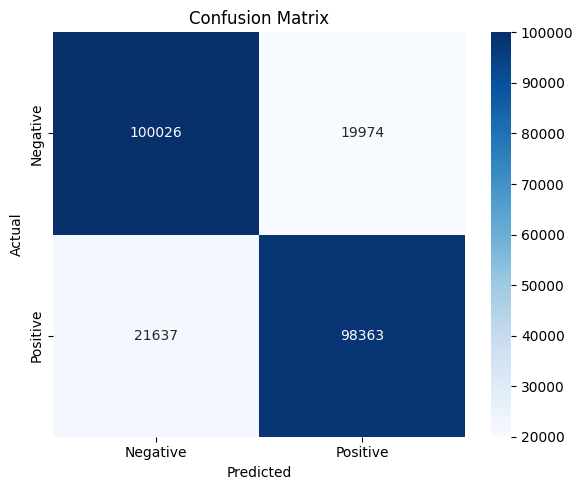

              precision    recall  f1-score   support

    Negative       0.82      0.83      0.83    120000
    Positive       0.83      0.82      0.83    120000

    accuracy                           0.83    240000
   macro avg       0.83      0.83      0.83    240000
weighted avg       0.83      0.83      0.83    240000



In [14]:
y_pred_probs = model.predict(test_ds)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

In [21]:
import os

# Save the trained sentiment model
os.makedirs(r'E:\Data Science\Projects\Sentiment Analysis\Models', exist_ok=True)
model.save(r'E:\Data Science\Projects\Sentiment Analysis\Models\sentiment_model.keras')

# Save the vectorizer as a TensorFlow SavedModel directory
vectorizer_model = tf.keras.Sequential([vectorizer])
vectorizer_model.save(r'E:\Data Science\Projects\Sentiment Analysis\Models\text_vectorizer', save_format='tf')
print("Model and Vectorizer saved successfully!")

INFO:tensorflow:Assets written to: E:\Data Science\Projects\Sentiment Analysis\Models\text_vectorizer\assets
Model and Vectorizer saved successfully!


In [22]:
# Load the model
loaded_model = tf.keras.models.load_model(r'E:\Data Science\Projects\Sentiment Analysis\Models\sentiment_model.keras')

# Load the vectorizer
loaded_vectorizer_model = tf.keras.models.load_model(r'E:\Data Science\Projects\Sentiment Analysis\Models\text_vectorizer')
loaded_vectorizer = loaded_vectorizer_model.layers[0]

print("Model and Vectorizer loaded successfully!")

Model and Vectorizer loaded successfully!
